# Chapter 9 · Ridgeline Plot of Temperature Change

A **ridgeline plot** (or *joyplot*) stacks many density curves so you can see how a
distribution shifts over time. Here we use it to show how the distribution of road-surface
temperature change (ΔT, relative to 2020) grows decade by decade under three climate
scenarios (SSP1-2.6, SSP2-4.5, SSP5-8.5).

```{admonition} This page is a runnable notebook
:class: tip
Read it here, or click the 🚀 launch button (*"Open in Colab"*) at the top of the page to run
it yourself.
```


## 0 · Setup

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip -q install seaborn
    import urllib.request
    BASE = "https://raw.githubusercontent.com/tongyuanwu/spatial-tutorial/main/book/data"
    os.makedirs("data", exist_ok=True)
    for f in ["Surface_temperature_126.csv", "Surface_temperature_245.csv", "Surface_temperature_585.csv"]:
        urllib.request.urlretrieve(f"{BASE}/{f}", f"data/{f}")

def find_data_dir(start=None):
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "data").is_dir():
            return p / "data"
    return Path("data")

DATA_DIR = find_data_dir()
print("Using DATA_DIR =", DATA_DIR)

Using DATA_DIR = D:\wty\Documents\GitHub\spatial-tutorial\book\data


### Step 1 · Libraries

`pandas`/`numpy` for the data, `scipy.stats.gaussian_kde` for the density estimate, and
`matplotlib`/`seaborn` for drawing.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
sns.set(style="white")

### Step 2 · File paths

Three CSVs, one per SSP scenario. Each holds a road id (`osm_id`) and a column of surface
temperature for every decade from 2020 to 2100.


In [3]:
csv_path = {
    "SSP126": DATA_DIR / "Surface_temperature_126.csv",
    "SSP245": DATA_DIR / "Surface_temperature_245.csv",
    "SSP585": DATA_DIR / "Surface_temperature_585.csv",
}

### Step 3 · Reshape and compute ΔT

We use the SSP2-4.5 value as the common 2020 baseline for every road, reshape each table
from wide (one column per year) to long with `pandas.melt`, and compute
**ΔT = T(year) − T(2020)** per road.


In [4]:
# Common 2020 baseline temperature per road, taken from SSP2-4.5
df_ssp245 = pd.read_csv(csv_path["SSP245"])
base_2020 = df_ssp245.set_index("osm_id")["2020"].to_dict()

year_cols = [str(y) for y in range(2020, 2101, 10)]
all_deltas = []
df_by_scenario = {}

for scenario, path in csv_path.items():
    df = pd.read_csv(path)

    # wide -> long: one row per (road, year)
    df_long = df.melt(id_vars=["osm_id"], value_vars=year_cols,
                      var_name="year", value_name="temperature")
    df_long["year"] = df_long["year"].astype(int)

    # overwrite each road's 2020 value with the shared baseline
    is_2020 = df_long["year"] == 2020
    df_long.loc[is_2020, "temperature"] = df_long.loc[is_2020, "osm_id"].map(base_2020)

    # ΔT = temperature - that road's 2020 baseline
    base = (df_long[df_long["year"] == 2020][["osm_id", "temperature"]]
            .rename(columns={"temperature": "base_2020"}))
    df_long = df_long.merge(base, on="osm_id", how="left")
    df_long["ΔT"] = df_long["temperature"] - df_long["base_2020"]

    df_by_scenario[scenario] = df_long[["year", "ΔT"]].copy()
    all_deltas.append(df_by_scenario[scenario]["ΔT"])

### Step 4 · A common x-axis

So the three scenarios are directly comparable, we estimate every density on the same grid
of ΔT values.


In [5]:
global_min = min(s.min() for s in all_deltas)
global_max = max(s.max() for s in all_deltas)
x_vals = np.linspace(global_min - 1, global_max + 1, 500)
x_range = (global_min - 1, global_max + 1)

### Step 5 · The ridgeline function

For each year (latest at the top) we estimate the ΔT density with `gaussian_kde`, offset it
vertically, fill it, and annotate the year and its mean.


In [6]:
def plot_ridgeline(df_delt, scenario_name):
    fig, ax = plt.subplots(figsize=(8, 10))
    years_sorted = sorted(df_delt["year"].unique())
    palette = sns.color_palette("coolwarm", len(years_sorted))[::-1]
    spacing = 0.8
    max_offset = (len(years_sorted) - 1) * spacing

    for i, year in enumerate(years_sorted[::-1]):
        offset = i * spacing
        data = df_delt[df_delt["year"] == year]["ΔT"].dropna().values
        if len(data) < 2:
            continue
        try:
            y_vals = gaussian_kde(data)(x_vals)
        except Exception:
            continue
        color = palette[i]
        ax.hlines(offset, *x_range, color=color, lw=1)
        ax.plot(x_vals, y_vals + offset, color=color, lw=1.5)
        ax.fill_between(x_vals, offset, y_vals + offset, color=color, alpha=0.9)
        ax.text(x_range[0] + 0.3, offset + 0.1, str(year),
                fontsize=9, color=color, ha="left", va="bottom", fontweight="bold")
        mean_val = np.mean(data)
        ax.vlines(mean_val, offset, offset + max(y_vals) * 0.95,
                  color="black", lw=2.0, linestyle="--", alpha=0.5)
        ax.text(mean_val, offset + max(y_vals) * 0.95 + 0.05, f"{mean_val:.1f}",
                ha="center", va="bottom", fontsize=7, color="black", alpha=0.8)

    for val in np.arange(int(x_range[0]), int(x_range[1]) + 1, 2):
        ax.text(val, -0.1, str(val), ha="center", va="top", fontsize=9)
    ax.text(0, -0.4, "ΔPavement surface temperature relative to 2020 (°C)",
            ha="center", va="top", fontsize=11, weight="bold")
    ax.text(x_range[0], max_offset + 0.5,
            f"ΔT Ridgeline — Pavement Surface Temperature Change ({scenario_name})",
            ha="left", va="bottom", fontsize=13, weight="bold")

    ax.set_xlim(*x_range)
    ax.set_ylim(-1, max_offset + 1.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines["bottom"].set_visible(False)
    sns.despine(left=True, top=True, right=True)
    ax.grid(False)
    plt.box(False)
    plt.show()

### Step 6 · Draw all three scenarios

One ridgeline per SSP scenario — read bottom-to-top as 2020 → 2100. Notice how the
distribution shifts further right (more warming) and the gap between scenarios widens.


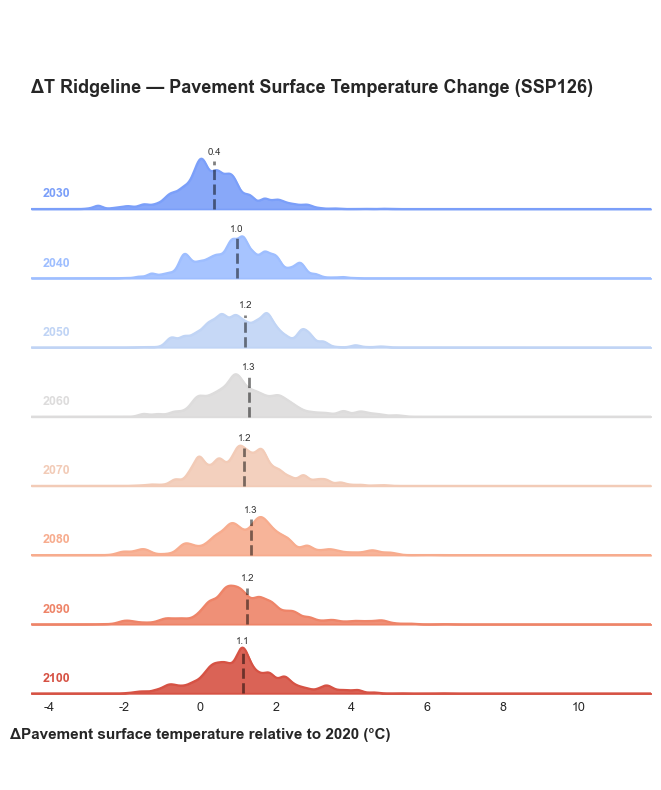

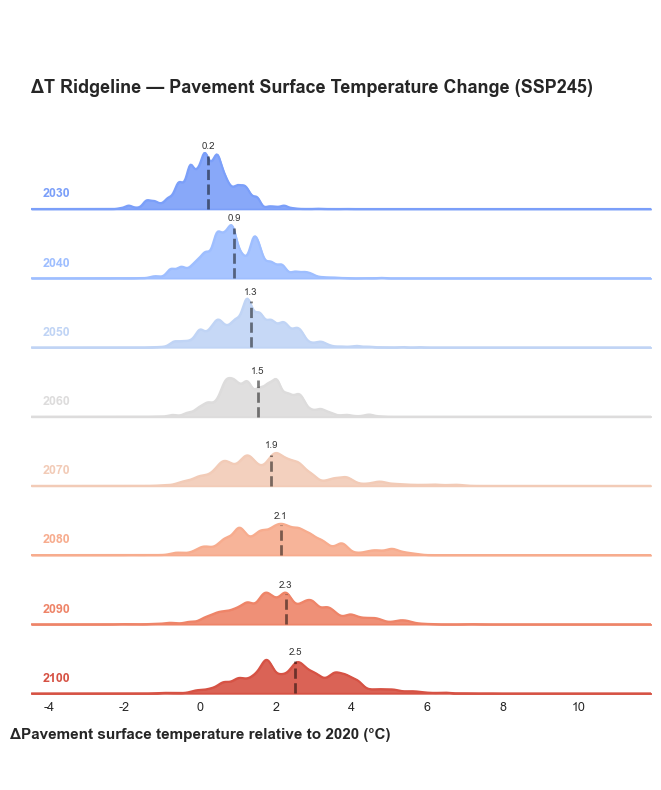

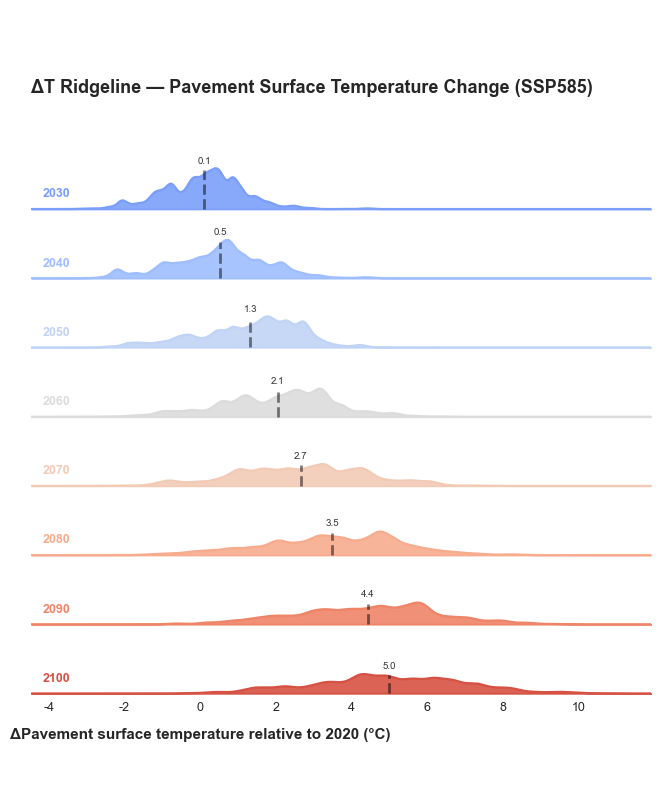

In [7]:
for name, df in df_by_scenario.items():
    plot_ridgeline(df, name)

```{admonition} Deliverable
:class: note
A ridgeline plot per climate scenario, showing the ΔT distribution shifting decade by decade.
```

```{seealso}
A *weighted* version of this plot (weighting each road by length) is documented as
reference-only in [](09b-weighted-ridgeline.md).
```

**Next:** put these numbers on a map in [](10-road-temp-map.ipynb).
